# 🎯 7. RAG-Powered Agents

In notebooks 01-06 of our RAG lectures series, we built sophisticated retrieval systems. Now we **connect them to agents** — creating agents that can search knowledge bases, evaluate results, and reason with retrieved evidence.

In this notebook:

1. **RAG recap** — the core retrieval pipeline
2. **From static to agentic RAG** — what changes when agents drive retrieval
3. **Retrieval as a tool** — wrapping vector search in a LangChain tool
4. **Building a RAG-powered agent** with LangGraph
5. **Iterative retrieval** — the maker-checker pattern
6. **Hybrid retrieval** — combining BM25 + vector search

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.documents import Document
from langchain_chroma import Chroma
from IPython.display import display, Markdown


# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"

llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
embedder = OpenAIEmbeddings(model=EMBED_MODEL)

print(f"Model: {LLM_MODEL} | Embeddings: {EMBED_MODEL}")


Model: gpt-4o-mini | Embeddings: text-embedding-3-small


## 7.1 Setting Up the Knowledge Base

We'll create a domain-specific knowledge base about AI agent frameworks:

In [3]:
# Knowledge base about AI agent frameworks
knowledge_base = [
    Document(page_content='LangGraph is a framework by LangChain for building stateful, graph-based agent workflows. It uses StateGraph with nodes and edges for agent orchestration. Key features: conditional edges, checkpointing, human-in-the-loop.', metadata={'source': 'frameworks.txt', 'topic': 'langgraph'}),
    Document(page_content='CrewAI is a framework for building role-based multi-agent systems. Each agent has a role, goal, and backstory. Agents collaborate through structured task delegation and shared context.', metadata={'source': 'frameworks.txt', 'topic': 'crewai'}),
    Document(page_content='AutoGen by Microsoft enables multi-agent conversation patterns. It supports group chat, agent handoffs, and distributed execution via gRPC. Agents can run on separate machines.', metadata={'source': 'frameworks.txt', 'topic': 'autogen'}),
    Document(page_content='The ReAct pattern combines reasoning and acting in an iterative loop. The agent generates a Thought, takes an Action via a tool, receives an Observation, and loops until reaching a final answer.', metadata={'source': 'patterns.txt', 'topic': 'react'}),
    Document(page_content='Function calling allows LLMs to invoke external tools by generating structured JSON describing the function name and arguments. OpenAI, Anthropic, and Google all support this pattern.', metadata={'source': 'patterns.txt', 'topic': 'tools'}),
    Document(page_content='Agent memory includes short-term (conversation history), long-term (persisted facts), and episodic (past experience). LangGraph supports checkpointing with SQLite and MemorySaver.', metadata={'source': 'patterns.txt', 'topic': 'memory'}),
    Document(page_content='MCP (Model Context Protocol) by Anthropic standardizes how LLMs connect to external tools and data. It uses a client-server architecture with three primitives: Tools, Resources, and Prompts.', metadata={'source': 'protocols.txt', 'topic': 'mcp'}),
    Document(page_content='A2A (Agent-to-Agent Protocol) by Google enables inter-agent communication. Components include Agent Cards (capability discovery), Executors (task processing), and Artifacts (work products).', metadata={'source': 'protocols.txt', 'topic': 'a2a'}),
    Document(page_content='Production agents require error handling (retry with backoff), cost optimization (model routing, caching), security (input validation, PII redaction), and observability (tracing with LangSmith or Langfuse).', metadata={'source': 'production.txt', 'topic': 'production'}),
    Document(page_content='Agent evaluation uses task completion rate, tool selection accuracy, reasoning quality, and cost per task. The evaluation flywheel: offline eval → deploy → monitor → collect failures → update test set → refine.', metadata={'source': 'evaluation.txt', 'topic': 'evaluation'}),
]

# Create vector store.
# For a teaching notebook this can be in-memory. In production, add persist_directory.
vectorstore = Chroma.from_documents(
    documents=knowledge_base,
    embedding=embedder,
    collection_name="ai_agents_kb",
)

# Use a threshold-aware retriever so unrelated queries can return no documents.
# Tune score_threshold depending on your dataset/embedding model.
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 3,
        "score_threshold": 0.15,
    },
)

print(f"Knowledge base: {len(knowledge_base)} documents indexed")


Knowledge base: 10 documents indexed


## 7.2 From Static RAG to Agentic RAG

| Aspect | Static RAG | Agentic RAG |
|--------|-----------|-------------|
| **Query** | User query → retrieve → answer | Agent decides *when* and *what* to retrieve |
| **Retrieval** | Always retrieves | Retrieves only when needed |
| **Iteration** | Single pass | Can re-query with improved terms |
| **Evaluation** | None | Agent evaluates if results are sufficient |
| **Tools** | Only retrieval | Retrieval + other tools combined |

The key insight: in agentic RAG, **retrieval is just another tool** the agent can choose to use.

## 7.3 Retrieval as a Tool

In [4]:
from langchain_core.tools import tool

@tool
def search_knowledge_base(query: str) -> str:
    """
    Search ONLY the local AI agents knowledge base.

    Use this tool for questions about LangGraph, CrewAI, AutoGen, ReAct,
    tool calling, agent memory, MCP, A2A, production agents, and agent evaluation.

    If the knowledge base does not contain enough information, return NO_RESULTS.
    """
    try:
        docs = retriever.invoke(query)
    except Exception as exc:
        return f"SEARCH_ERROR: {type(exc).__name__}: {exc}"

    if not docs:
        return (
            "NO_RESULTS: No relevant documents were found in the local knowledge base "
            f"for query: {query!r}."
        )

    results = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        topic = doc.metadata.get("topic", "unknown")
        content = doc.page_content.strip()

        # Keep tool observations compact.
        if len(content) > 1200:
            content = content[:1200] + "..."

        results.append(
            f"[{i}] Source: `{source}`\n\n Topic: `{topic}`\n\n"
            f"{content}"
        )

    return "FOUND_RESULTS:\n\n" + "\n\n".join(results)

# Test the tool
result = search_knowledge_base.invoke({"query": "LangGraph features"})
display(Markdown(result))


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='2b87c23a-6d16-453b-9395-d98d55f345d1', metadata={'source': 'frameworks.txt', 'topic': 'langgraph'}, page_content='LangGraph is a framework by LangChain for building stateful, graph-based agent workflows. It uses StateGraph with nodes and edges for agent orchestration. Key features: conditional edges, checkpointing, human-in-the-loop.'), 0.5152406461534629), (Document(id='82432ac3-1fc1-4ea9-a4db-5f375e84c3e6', metadata={'source': 'patterns.txt', 'topic': 'memory'}, page_content='Agent memory includes short-term (conversation history), long-term (persisted facts), and episodic (past experience). LangGraph supports checkpointing with SQLite and MemorySaver.'), 0.1566763745938805), (Document(id='490be9e2-1dab-4e23-9846-7d60810f25bb', metadata={'topic': 'tools', 'source': 'patterns.txt'}, page_content='Function c

FOUND_RESULTS:

[1] Source: `frameworks.txt`

 Topic: `langgraph`

LangGraph is a framework by LangChain for building stateful, graph-based agent workflows. It uses StateGraph with nodes and edges for agent orchestration. Key features: conditional edges, checkpointing, human-in-the-loop.

[2] Source: `patterns.txt`

 Topic: `memory`

Agent memory includes short-term (conversation history), long-term (persisted facts), and episodic (past experience). LangGraph supports checkpointing with SQLite and MemorySaver.

## 7.4 Building a RAG-Powered Agent with LangGraph

<img src="images/rag-powered-agent.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

### 7.4.1 Explicit LangGraph approach


In [5]:
from typing import Literal

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import MessagesState

# Tools available to the agent
tools = [search_knowledge_base]
llm_with_tools = llm.bind_tools(tools)

MAX_RETRIEVALS = 2


def count_retrievals(state: MessagesState) -> int:
    """Count how many tool observations exist in the current graph state."""
    return sum(isinstance(message, ToolMessage) for message in state["messages"])


# Agent node
def agent(state: MessagesState) -> dict:
    retrievals = count_retrievals(state)

    if retrievals >= MAX_RETRIEVALS:
        # Final answer pass: remove tools to force termination.
        system = SystemMessage(content=(
            "You are an AI agents expert. "
            "You have already searched the local knowledge base. "
            "Do not call tools anymore. "
            "If the retrieved context is missing, unrelated, or contains NO_RESULTS, "
            "say clearly that the knowledge base does not contain enough information. "
            "Do not invent facts or sources."
        ))
        response = llm.invoke([system] + state["messages"])
    else:
        # Tool-enabled pass.
        system = SystemMessage(content=(
            "You are an AI agents expert. "
            "Use the search_knowledge_base tool for questions about AI-agent frameworks, "
            "patterns, protocols, production practices, and evaluation. "
            "Always cite retrieved sources using their Source labels. "
            "If the tool returns NO_RESULTS or unrelated context, do not keep searching forever; "
            "answer that the knowledge base is insufficient."
        ))
        response = llm_with_tools.invoke([system] + state["messages"])

    return {"messages": [response]}


# Router
def should_retrieve(state: MessagesState) -> Literal["retrieve", "__end__"]:
    last = state["messages"][-1]
    retrievals = count_retrievals(state)

    if getattr(last, "tool_calls", None) and retrievals < MAX_RETRIEVALS:
        return "retrieve"

    return END


# Build graph
rag_graph = StateGraph(MessagesState)

rag_graph.add_node("agent", agent)
rag_graph.add_node("retrieve", ToolNode(tools))

rag_graph.add_edge(START, "agent")

rag_graph.add_conditional_edges(
    "agent",
    should_retrieve,
    {
        "retrieve": "retrieve",
        END: END,
    },
)

rag_graph.add_edge("retrieve", "agent")  # After retrieval, back to agent.

rag_graph_app = rag_graph.compile()
print("Explicit LangGraph RAG-powered agent compiled!")


Explicit LangGraph RAG-powered agent compiled!


In [5]:
# Test the explicit LangGraph RAG agent
questions = [
    "What is LangGraph and what are its key features?",
    "How does MCP differ from A2A protocol?",
    "What patterns are used for agent evaluation in production?",
    "What is the main purpose of Datanous AI company?",
]

for q in questions:
    print(f"\n{'='*60}")
    display(Markdown(f"**Q: {q}**"))

    result = rag_graph_app.invoke(
        {"messages": [HumanMessage(content=q)]},
        config={"recursion_limit": 8},
    )

    display(Markdown(f"A: {result['messages'][-1].content}"))


**Q: What is LangGraph and what are its key features?**

A: LangGraph is a framework developed by LangChain designed for building stateful, graph-based agent workflows. Here are its key features:

1. **StateGraph**: Utilizes a graph structure with nodes and edges to orchestrate agents effectively.
2. **Conditional Edges**: Allows for dynamic decision-making within the workflow based on specific conditions.
3. **Checkpointing**: Supports saving the state of the workflow, enabling recovery and continuity.
4. **Human-in-the-Loop**: Facilitates human intervention in the workflow, enhancing the decision-making process.

These features make LangGraph a powerful tool for creating complex agent interactions and workflows. [Source: frameworks.txt]

**Q: How does MCP differ from A2A protocol?**

A: MCP (Model Context Protocol) and A2A (Agent-to-Agent Protocol) are both protocols used in the context of AI agents, but they serve different purposes and have distinct architectures.

1. **MCP (Model Context Protocol)**:
   - Developed by Anthropic, MCP standardizes how large language models (LLMs) connect to external tools and data.
   - It employs a client-server architecture and includes three main components: Tools, Resources, and Prompts. This structure facilitates the interaction between the model and external resources.

2. **A2A (Agent-to-Agent Protocol)**:
   - Created by Google, A2A focuses on enabling communication between different agents.
   - Its components include Agent Cards (for capability discovery), Executors (for task processing), and Artifacts (which represent the work products generated by agents). This protocol is designed to facilitate collaboration and task execution among multiple agents.

In summary, MCP is primarily about connecting LLMs to external tools, while A2A is centered on communication and collaboration between agents.

**Q: What patterns are used for agent evaluation in production?**

A: In production, agent evaluation typically employs several key patterns:

1. **Task Completion Rate**: This measures the percentage of tasks that the agent successfully completes, providing a direct indicator of its effectiveness.

2. **Tool Selection Accuracy**: This evaluates how accurately the agent selects the appropriate tools for the tasks it is handling.

3. **Reasoning Quality**: This assesses the logical reasoning capabilities of the agent, determining how well it can process information and make decisions.

4. **Cost per Task**: This metric looks at the financial efficiency of the agent, analyzing the cost associated with completing each task.

Additionally, there is an evaluation flywheel process that includes:
- **Offline Evaluation**: Testing the agent in a controlled environment before deployment.
- **Deployment**: Launching the agent into a live environment.
- **Monitoring**: Continuously observing the agent's performance.
- **Collecting Failures**: Gathering data on any failures or issues encountered.
- **Updating Test Set**: Modifying the test scenarios based on collected data.
- **Refining**: Improving the agent based on insights gained from the evaluation process.

These patterns help ensure that agents are not only effective but also efficient and reliable in production settings (Source: evaluation.txt).

**Q: What is the main purpose of Datanous AI company?**

c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='f67f792e-03df-4afd-afff-e34a86f1b6bd', metadata={'source': 'frameworks.txt', 'topic': 'crewai'}, page_content='CrewAI is a framework for building role-based multi-agent systems. Each agent has a role, goal, and backstory. Agents collaborate through structured task delegation and shared context.'), 0.053410442302307515), (Document(id='11b9bf07-4dc4-4720-b544-fed87b2114f7', metadata={'source': 'protocols.txt', 'topic': 'a2a'}, page_content='A2A (Agent-to-Agent Protocol) by Google enables inter-agent communication. Components include Agent Cards (capability discovery), Executors (task processing), and Artifacts (work products).'), -0.03208266973440366), (Document(id='f686e8cb-5961-4e5e-8436-7e7cb19da36b', metadata={'source': 'frameworks.txt', 'topic': 'autogen'}, page_content='AutoGen by Microsoft enables multi

A: The knowledge base is insufficient to provide information about the main purpose of Datanous AI company.

### 7.4.2 Same implementation using create_agent

```                                     
    User question                        
    ↓                                    
    LLM / agent                          
    ↓                                    
    Αποφασίζει αν χρειάζεται tool call   
    ↓                                    
    Αν ναι → καλεί search_knowledge_base 
    ↓                                    
    Παίρνει retrieved context            
    ↓                                    
    Επιστρέφει ξανά στο LLM              
    ↓                                    
    Τελική απάντηση                      
```


- Το **create_agent** είναι high-level factory.
- Χτίζει έτοιμη agent αρχιτεκτονική πάνω σε LangGraph.
- Το LLM αποφασίζει αν θα καλέσει το retrieval tool.
- Αν το καλέσει, το αποτέλεσμα επιστρέφει ξανά στον agent.
- Αν δεν το καλέσει, ο agent απαντά και τερματίζει.

In [6]:
# Agentic RAG με factory pattern:
# Το retrieval γίνεται @tool και το create_agent χτίζει έτοιμο LangGraph-based agent runtime.
from langchain.agents import create_agent

rag_factory_app = create_agent(
    model=llm,
    tools=[search_knowledge_base],
    system_prompt=(
        "You are an AI agents expert. "
        "Use the search_knowledge_base tool for questions about AI-agent frameworks, "
        "patterns, protocols, production practices, and evaluation. "
        "Always cite retrieved sources using their Source labels. "
        "If the tool returns NO_RESULTS or unrelated context, say that the local knowledge base "
        "does not contain enough information. Do not invent facts or sources."
    ),
)


In [7]:
# Test the factory RAG agent
questions = [
    "What is LangGraph and what are its key features?",
    "How does MCP differ from A2A protocol?",
    "What patterns are used for agent evaluation in production?",
    "What is the main purpose of Datanous AI company?",
    "Which is the capital of France?"
]

for q in questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")

    result = rag_factory_app.invoke(
        {"messages": [HumanMessage(content=q)]},
        config={"recursion_limit": 8},
    )

    display(Markdown(f"A: {result['messages'][-1].content}"))



Q: What is LangGraph and what are its key features?


A: LangGraph is a framework developed by LangChain for creating stateful, graph-based agent workflows. Here are its key features:

1. **StateGraph**: Utilizes nodes and edges for orchestrating agents, allowing for complex workflows.
2. **Conditional Edges**: Supports dynamic decision-making within the workflow based on specific conditions.
3. **Checkpointing**: Enables saving the state of the workflow, which can be useful for recovery and analysis.
4. **Human-in-the-Loop**: Facilitates human intervention in the workflow, allowing for adjustments and oversight.

These features make LangGraph a powerful tool for building sophisticated AI agent systems. [Source: frameworks.txt]


Q: How does MCP differ from A2A protocol?


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='de244184-3e79-4efd-9850-fbc51d1b1806', metadata={'source': 'protocols.txt', 'topic': 'mcp'}, page_content='MCP (Model Context Protocol) by Anthropic standardizes how LLMs connect to external tools and data. It uses a client-server architecture with three primitives: Tools, Resources, and Prompts.'), 0.25663656096934995), (Document(id='892db53e-4ee1-45fc-a5d5-f516170bb4da', metadata={'source': 'protocols.txt', 'topic': 'a2a'}, page_content='A2A (Agent-to-Agent Protocol) by Google enables inter-agent communication. Components include Agent Cards (capability discovery), Executors (task processing), and Artifacts (work products).'), 0.08683550627605419), (Document(id='27544366-2ced-4a02-8600-b205863ccd97', metadata={'source': 'frameworks.txt', 'topic': 'autogen'}, page_content='AutoGen by Microsoft enables multi

A: MCP (Model Context Protocol) and A2A (Agent-to-Agent Protocol) serve different purposes in the realm of AI agents.

1. **MCP (Model Context Protocol)**:
   - Developed by Anthropic, MCP standardizes how large language models (LLMs) connect to external tools and data.
   - It employs a client-server architecture and consists of three main components: Tools, Resources, and Prompts. This structure facilitates the interaction between the model and external resources effectively.

2. **A2A (Agent-to-Agent Protocol)**:
   - Created by Google, A2A focuses on enabling communication between different agents.
   - Its components include Agent Cards (for capability discovery), Executors (for processing tasks), and Artifacts (which are the work products generated by agents). This protocol is designed to enhance collaboration and task execution among multiple agents.

In summary, MCP is centered around LLMs interacting with external tools, while A2A is about facilitating communication and collaboration between different agents.

...


Q: What is the main purpose of Datanous AI company?


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='cc67f060-03f4-4060-935d-af2ce7ec106a', metadata={'source': 'frameworks.txt', 'topic': 'crewai'}, page_content='CrewAI is a framework for building role-based multi-agent systems. Each agent has a role, goal, and backstory. Agents collaborate through structured task delegation and shared context.'), 0.052917071293638984), (Document(id='892db53e-4ee1-45fc-a5d5-f516170bb4da', metadata={'source': 'protocols.txt', 'topic': 'a2a'}, page_content='A2A (Agent-to-Agent Protocol) by Google enables inter-agent communication. Components include Agent Cards (capability discovery), Executors (task processing), and Artifacts (work products).'), -0.032156089544509436), (Document(id='27544366-2ced-4a02-8600-b205863ccd97', metadata={'source': 'frameworks.txt', 'topic': 'autogen'}, page_content='AutoGen by Microsoft enables mult

A: The local knowledge base does not contain enough information about the purpose of Datanous AI company.


Q: Which is the capital of France?


A: The local knowledge base does not contain enough information.

### 7.4.3. -> **Dimitris** is here! :D

In [8]:
# Agentic RAG με factory pattern:
# Το retrieval γίνεται @tool και το create_agent χτίζει έτοιμο LangGraph-based agent runtime.
from langchain.agents import create_agent

rag_factory_app = create_agent(
    model=llm,
    tools=[search_knowledge_base],
    system_prompt=(
        "You are an AI agents expert. "
        "Use the search_knowledge_base tool for questions about AI-agent frameworks, "
        "patterns, protocols, production practices, and evaluation. "
        "Always cite retrieved sources using their Source labels. "
        "If the tool returns NO_RESULTS or unrelated context, "
        "answer based on your own knowledge BUT clearly state: "
        "'Note: The local knowledge base had no matching documents; "
        "this answer is based on general training knowledge.'"
    ),
)


In [9]:
# Test the factory RAG agent
questions = [
    "What is LangGraph and what are its key features?",
    "How does MCP differ from A2A protocol?",
    "What patterns are used for agent evaluation in production?",
    "What is the main purpose of Datanous AI company?",
]

for q in questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")

    result = rag_factory_app.invoke(
        {"messages": [HumanMessage(content=q)]},
        config={"recursion_limit": 8},
    )

    display(Markdown(f"A: {result['messages'][-1].content}"))



Q: What is LangGraph and what are its key features?


A: LangGraph is a framework developed by LangChain designed for building stateful, graph-based agent workflows. Here are its key features:

1. **StateGraph**: Utilizes a graph structure with nodes and edges to orchestrate agent workflows effectively.
2. **Conditional Edges**: Allows for dynamic decision-making within the workflow based on specific conditions.
3. **Checkpointing**: Supports saving the state of the workflow, which can be useful for resuming processes or maintaining continuity.
4. **Human-in-the-Loop**: Facilitates human intervention in the workflow, enabling better oversight and control over the agent's actions.

These features make LangGraph a powerful tool for creating complex agent interactions and workflows. [Source: frameworks.txt]


Q: How does MCP differ from A2A protocol?


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='de244184-3e79-4efd-9850-fbc51d1b1806', metadata={'source': 'protocols.txt', 'topic': 'mcp'}, page_content='MCP (Model Context Protocol) by Anthropic standardizes how LLMs connect to external tools and data. It uses a client-server architecture with three primitives: Tools, Resources, and Prompts.'), 0.5332513853681689), (Document(id='27544366-2ced-4a02-8600-b205863ccd97', metadata={'topic': 'autogen', 'source': 'frameworks.txt'}, page_content='AutoGen by Microsoft enables multi-agent conversation patterns. It supports group chat, agent handoffs, and distributed execution via gRPC. Agents can run on separate machines.'), -0.02117051348014498), (Document(id='23d02595-44e9-4fc9-af3b-3917c80d0bbe', metadata={'topic': 'production', 'source': 'production.txt'}, page_content='Production agents require error handlin

A: MCP (Model Context Protocol) and A2A (Agent-to-Agent Protocol) serve different purposes in the realm of AI agents.

1. **MCP (Model Context Protocol)**:
   - Developed by Anthropic, MCP standardizes how large language models (LLMs) connect to external tools and data.
   - It employs a client-server architecture and consists of three main components: Tools, Resources, and Prompts. This structure allows LLMs to effectively utilize external resources and tools in their operations.
   - Source: [protocols.txt]

2. **A2A (Agent-to-Agent Protocol)**:
   - Created by Google, A2A facilitates communication between different agents.
   - Key components of A2A include Agent Cards (for capability discovery), Executors (for processing tasks), and Artifacts (which are the work products generated by agents).
   - This protocol is designed to enhance collaboration and task execution among multiple agents.
   - Source: [protocols.txt]

In summary, MCP focuses on the interaction between LLMs and external tools, while A2A emphasizes communication and collaboration between different agents.


Q: What patterns are used for agent evaluation in production?


A: In production, agent evaluation typically employs several key patterns, including:

1. **Task Completion Rate**: This measures how effectively the agent completes assigned tasks.
2. **Tool Selection Accuracy**: This evaluates how well the agent selects the appropriate tools for the tasks at hand.
3. **Reasoning Quality**: This assesses the logical reasoning capabilities of the agent in making decisions.
4. **Cost per Task**: This analyzes the financial efficiency of the agent in completing tasks.

Additionally, there is an evaluation flywheel process that includes:
- **Offline Evaluation**: Testing the agent in a controlled environment before deployment.
- **Deployment**: Releasing the agent into a production environment.
- **Monitoring**: Continuously observing the agent's performance.
- **Collecting Failures**: Gathering data on any failures or issues encountered.
- **Updating Test Set**: Refining the evaluation criteria based on collected data.
- **Refinement**: Making improvements to the agent based on insights gained from monitoring and failures.

These patterns help ensure that agents are effective, efficient, and continuously improving in a production setting (Source: evaluation.txt).


Q: What is the main purpose of Datanous AI company?


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langchain_core\vectorstores\base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='cc67f060-03f4-4060-935d-af2ce7ec106a', metadata={'source': 'frameworks.txt', 'topic': 'crewai'}, page_content='CrewAI is a framework for building role-based multi-agent systems. Each agent has a role, goal, and backstory. Agents collaborate through structured task delegation and shared context.'), 0.05302656880607026), (Document(id='892db53e-4ee1-45fc-a5d5-f516170bb4da', metadata={'topic': 'a2a', 'source': 'protocols.txt'}, page_content='A2A (Agent-to-Agent Protocol) by Google enables inter-agent communication. Components include Agent Cards (capability discovery), Executors (task processing), and Artifacts (work products).'), -0.03208266973440366), (Document(id='27544366-2ced-4a02-8600-b205863ccd97', metadata={'source': 'frameworks.txt', 'topic': 'autogen'}, page_content='AutoGen by Microsoft enables multi-

A: Note: The local knowledge base had no matching documents; this answer is based on general training knowledge.

Datanous AI is primarily focused on providing AI-driven solutions for data management and analytics. The company aims to help organizations leverage their data more effectively by offering tools and platforms that enhance data accessibility, quality, and insights. Their solutions often involve automating data processes, improving decision-making through advanced analytics, and enabling businesses to harness the power of AI for better operational efficiency.

### 7.4.4. Explicitly detect tool calls

In [10]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

def inspect_agent_run(agent, question: str):
    result = agent.invoke({
        "messages": [HumanMessage(content=question)]
    })

    print("\n" + "=" * 80)
    print(f"QUESTION: {question}")
    print("=" * 80)

    tool_used = False

    print("\nFULL MESSAGE TRACE")
    print("-" * 80)

    for i, msg in enumerate(result["messages"]):
        print(f"\n[{i}] {msg.__class__.__name__}")
        msg.pretty_print()

    print("\nTOOL USAGE SUMMARY")
    print("-" * 80)

    for msg in result["messages"]:

        if isinstance(msg, AIMessage):
            tool_calls = getattr(msg, "tool_calls", None)

            if tool_calls:
                tool_used = True

                for call in tool_calls:
                    print("LLM requested tool:")
                    print(f"  Tool name : {call.get('name')}")
                    print(f"  Arguments : {call.get('args')}")
                    print(f"  Call ID   : {call.get('id')}")
                    print()

        elif isinstance(msg, ToolMessage):
            tool_used = True

            print("Tool returned result:")
            print(f"  Tool name    : {getattr(msg, 'name', 'unknown')}")
            print(f"  Tool call ID : {getattr(msg, 'tool_call_id', 'unknown')}")
            print("  Content:")
            print(msg.content[:1000])
            print()

    print(f"TOOL USED? {tool_used}")

    final_answer = result["messages"][-1].content

    print("\nFINAL ANSWER")
    print("-" * 80)
    print(final_answer)

    return result

inspect_agent_run(
    rag_factory_app,
    "What is LangGraph and what are its key features?"
    # "Which is the capital of France?"
)


QUESTION: What is LangGraph and what are its key features?

FULL MESSAGE TRACE
--------------------------------------------------------------------------------

[0] HumanMessage
================================ Human Message =================================

What is LangGraph and what are its key features?

[1] AIMessage
================================== Ai Message ==================================
Tool Calls:
  search_knowledge_base (call_HQRxlBM8wCWpYusd7R7SGee8)
 Call ID: call_HQRxlBM8wCWpYusd7R7SGee8
  Args:
    query: LangGraph key features

[2] ToolMessage
================================= Tool Message =================================
Name: search_knowledge_base

FOUND_RESULTS:

[1] Source: `frameworks.txt`

 Topic: `langgraph`

LangGraph is a framework by LangChain for building stateful, graph-based agent workflows. It uses StateGraph with nodes and edges for agent orchestration. Key features: conditional edges, checkpointing, human-in-the-loop.

[2] Source: `patterns.txt`


{'messages': [HumanMessage(content='What is LangGraph and what are its key features?', additional_kwargs={}, response_metadata={}, id='74cd5621-6451-44a8-904f-e013fdd05263'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 191, 'total_tokens': 210, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c2f5782bd4', 'id': 'chatcmpl-DizfJjLZWwdEbRmiXCdvK7jd5by8J', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e595e-cd8a-7aa2-826a-f870f0879f11-0', tool_calls=[{'name': 'search_knowledge_base', 'args': {'query': 'LangGraph key features'}, 'id': 'call_HQRxlBM8wCWpYusd7R7SGee8', 'type': 'tool_call'}], invalid_tool_call

## 7.5 Iterative Retrieval — The Maker-Checker Pattern

In agentic RAG, the agent can **evaluate** whether retrieved documents are sufficient and re-query if needed:

<img src="images/iterative-retrieval.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

This self-correcting behavior is what makes agentic RAG superior to static RAG.

### 7.5.1. Using langgraph

In [11]:
from __future__ import annotations

from typing import Literal
from typing_extensions import TypedDict, NotRequired

from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END


# 1. Structured evaluation schema
class RetrievalEvaluation(BaseModel):
    """Evaluate whether retrieved documents are sufficient."""
    is_sufficient: bool = Field(
        description="Whether the documents fully answer the question"
    )
    reasoning: str = Field(
        description="Why the documents are or are not sufficient"
    )
    improved_query: str = Field(
        default="",
        description="Better search query if not sufficient"
    )


evaluator = llm.with_structured_output(RetrievalEvaluation)


# 2. Utility functions
def format_docs(docs: list[Document]) -> str:
    """Format documents with metadata so the final answer can cite sources."""
    formatted = []

    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        topic = doc.metadata.get("topic", "unknown")

        formatted.append(
            f"[{i}] Source: {source} | Topic: {topic}\n"
            f"{doc.page_content.strip()}"
        )

    return "\n\n".join(formatted)


def dedupe_docs(docs: list[Document]) -> list[Document]:
    """Remove duplicate documents while preserving order."""
    seen = set()
    unique_docs = []

    for doc in docs:
        key = (
            doc.metadata.get("source", "unknown"),
            doc.metadata.get("topic", "unknown"),
            doc.page_content,
        )

        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)

    return unique_docs

In [12]:
# 3. LangGraph state
class IterativeRAGState(TypedDict):
    question: str

    query: NotRequired[str]
    attempt: NotRequired[int]
    max_attempts: NotRequired[int]

    last_docs: NotRequired[list[Document]]
    docs: NotRequired[list[Document]]

    evaluation: NotRequired[RetrievalEvaluation]
    answer: NotRequired[str]

    trace: NotRequired[list[str]]

In [13]:
# 4. Graph nodes
def query_node(state: IterativeRAGState) -> IterativeRAGState:
    """1. Query"""
    question = state["question"].strip()

    return {
        "query": question,
        "attempt": 0,
        "max_attempts": state.get("max_attempts", 3),
        "docs": [],
        "last_docs": [],
        "answer": "",
        "trace": [f"Initial query: {question}"],
    }


def retrieve_node(state: IterativeRAGState) -> IterativeRAGState:
    """2. Retrieve"""
    query = state["query"]
    attempt = state.get("attempt", 0) + 1

    docs = retriever.invoke(query)

    previous_docs = state.get("docs", [])
    unique_docs = dedupe_docs(previous_docs + docs)

    trace = state.get("trace", [])
    trace.append(
        f"Attempt {attempt}: retrieved {len(docs)} documents using query: {query!r}"
    )

    return {
        "attempt": attempt,
        "last_docs": docs,
        "docs": unique_docs,
        "trace": trace,
    }


def evaluate_relevance_node(state: IterativeRAGState) -> IterativeRAGState:
    """3. Evaluate relevance"""
    question = state["question"]
    query = state["query"]

    # Evaluate accumulated unique docs, not only the latest retrieval.
    # This matters because attempt 1 may retrieve LangGraph docs,
    # attempt 2 CrewAI docs, attempt 3 AutoGen docs, etc.
    docs = state.get("docs", [])
    doc_text = format_docs(docs)

    if not doc_text:
        doc_text = "No documents were retrieved."

    evaluation = evaluator.invoke([
        SystemMessage(content=(
            "Evaluate whether the retrieved documents are sufficient to answer the question. "
            "If a required entity, framework, comparison point, or concept is missing, "
            "mark is_sufficient=false. "
            "If you suggest an improved query, make it meaningfully different from the current one. "
            "The improved query should help retrieve the missing information."
        )),
        HumanMessage(content=(
            f"Original question: {question}\n"
            f"Current query: {query}\n\n"
            f"Retrieved documents:\n{doc_text}"
        )),
    ])

    trace = state.get("trace", [])
    trace.append(f"Sufficient: {evaluation.is_sufficient}")
    trace.append(f"Reasoning: {evaluation.reasoning}")

    if not evaluation.is_sufficient and evaluation.improved_query:
        trace.append(f"Suggested refined query: {evaluation.improved_query}")

    return {
        "evaluation": evaluation,
        "trace": trace,
    }


def re_query_node(state: IterativeRAGState) -> IterativeRAGState:
    """5. Re-query"""
    evaluation = state["evaluation"]
    improved_query = evaluation.improved_query.strip()

    trace = state.get("trace", [])
    trace.append(f"Refined query selected: {improved_query}")

    return {
        "query": improved_query,
        "trace": trace,
    }


def answer_node(state: IterativeRAGState) -> IterativeRAGState:
    """4. Answer"""
    question = state["question"]
    docs = dedupe_docs(state.get("docs", []))
    evaluation = state.get("evaluation")

    if not docs:
        return {
            "answer": (
                "I could not find relevant information in the local knowledge base, "
                "so I cannot answer this reliably from the provided sources."
            )
        }

    all_context = format_docs(docs)

    if evaluation and not evaluation.is_sufficient:
        answer_policy = (
            "The retrieved context may be incomplete. "
            "Answer only the parts supported by the context and explicitly mention missing information."
        )
    else:
        answer_policy = "Answer based only on the provided context."

    response = llm.invoke([
        SystemMessage(content=(
            f"{answer_policy} "
            "Cite sources using the exact Source labels from the context. "
            "Do not invent missing facts."
        )),
        HumanMessage(content=(
            f"Context:\n{all_context}\n\n"
            f"Question: {question}"
        )),
    ])

    trace = state.get("trace", [])
    trace.append("Final answer generated.")

    return {
        "answer": response.content,
        "trace": trace,
    }

In [14]:
# 5. Conditional routing
def route_after_evaluation(
    state: IterativeRAGState,
) -> Literal["answer", "re_query"]:
    evaluation = state.get("evaluation")
    attempt = state.get("attempt", 0)
    max_attempts = state.get("max_attempts", 3)

    if evaluation is None:
        return "answer"

    if evaluation.is_sufficient:
        return "answer"

    if attempt >= max_attempts:
        return "answer"

    improved_query = evaluation.improved_query.strip()
    current_query = state.get("query", "").strip()

    if not improved_query:
        return "answer"

    if improved_query == current_query:
        return "answer"

    return "re_query"

In [15]:
# 6. Build the LangGraph workflow

builder = StateGraph(IterativeRAGState)

builder.add_node("query", query_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("evaluate_relevance", evaluate_relevance_node)
builder.add_node("re_query", re_query_node)
builder.add_node("answer", answer_node)

builder.add_edge(START, "query")
builder.add_edge("query", "retrieve")
builder.add_edge("retrieve", "evaluate_relevance")

builder.add_conditional_edges(
    "evaluate_relevance",
    route_after_evaluation,
    {
        "answer": "answer",
        "re_query": "re_query",
    },
)

builder.add_edge("re_query", "retrieve")
builder.add_edge("answer", END)

iterative_rag_graph = builder.compile()

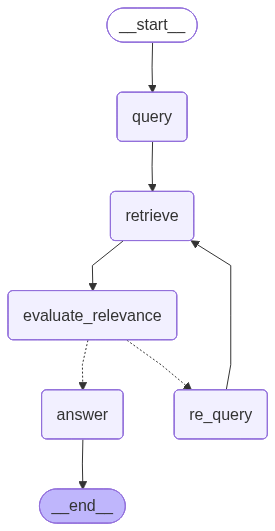

In [17]:
from IPython.display import Image, display

display(Image(iterative_rag_graph.get_graph().draw_mermaid_png()))

In [16]:
result = iterative_rag_graph.invoke({
    "question": "Compare the multi-agent capabilities of LangGraph, CrewAI, and AutoGen",
    "max_attempts": 3,
})

display(Markdown("## Trace"))
display(Markdown("\n\n".join(result["trace"])))

display(Markdown("## Final Answer"))
display(Markdown(result["answer"]))

## Trace

Initial query: Compare the multi-agent capabilities of LangGraph, CrewAI, and AutoGen

Attempt 1: retrieved 3 documents using query: 'Compare the multi-agent capabilities of LangGraph, CrewAI, and AutoGen'

Sufficient: True

Reasoning: The retrieved documents provide a clear comparison of the multi-agent capabilities of LangGraph, CrewAI, and AutoGen. Each document outlines the key features and functionalities of the respective frameworks, allowing for a comprehensive understanding of their multi-agent capabilities.

Final answer generated.

## Final Answer

LangGraph, CrewAI, and AutoGen each offer distinct multi-agent capabilities tailored to different use cases.

1. **LangGraph**: This framework focuses on building stateful, graph-based agent workflows. It utilizes a StateGraph structure with nodes and edges for orchestrating agents. Key features include conditional edges, checkpointing, and the ability to incorporate human-in-the-loop interactions, which allows for dynamic decision-making and adaptability in agent workflows [1].

2. **CrewAI**: In contrast, CrewAI is designed for role-based multi-agent systems where each agent has a specific role, goal, and backstory. This framework emphasizes collaboration among agents through structured task delegation and shared context, making it suitable for scenarios where agents need to work together towards common objectives while maintaining individual identities [2].

3. **AutoGen**: Developed by Microsoft, AutoGen enables multi-agent conversation patterns and supports functionalities like group chat, agent handoffs, and distributed execution via gRPC. This framework allows agents to operate on separate machines, facilitating scalability and flexibility in multi-agent interactions [3].

In summary, LangGraph excels in orchestrating complex workflows with state management, CrewAI focuses on collaborative role-based interactions, and AutoGen provides robust support for conversational patterns and distributed execution.

### 7.5.2.  Using simple function - understanding the concept

In [46]:
from pydantic import BaseModel, Field


class RetrievalEvaluation(BaseModel):
    """Evaluate whether retrieved documents are sufficient."""
    is_sufficient: bool = Field(description="Whether the documents fully answer the question")
    reasoning: str = Field(description="Why the documents are or are not sufficient")
    improved_query: str = Field(default="", description="Better search query if not sufficient")


evaluator = llm.with_structured_output(RetrievalEvaluation)


def format_docs(docs: list[Document]) -> str:
    """Format documents with metadata so the final answer can cite sources."""
    formatted = []

    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        topic = doc.metadata.get("topic", "unknown")
        formatted.append(
            f"[{i}] Source: {source} | Topic: {topic}\n"
            f"{doc.page_content.strip()}"
        )

    return "\n\n".join(formatted)


def dedupe_docs(docs: list[Document]) -> list[Document]:
    """Remove duplicate documents while preserving order."""
    seen = set()
    unique_docs = []

    for doc in docs:
        key = (
            doc.metadata.get("source", "unknown"),
            doc.metadata.get("topic", "unknown"),
            doc.page_content,
        )

        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)

    return unique_docs


def iterative_rag(question: str, max_attempts: int = 3) -> str:
    """RAG with self-evaluation and query refinement."""
    query = question
    all_docs = []
    final_evaluation = None

    for attempt in range(1, max_attempts + 1):
        print(f"\n  Attempt {attempt}: Searching for {query!r}")

        docs = retriever.invoke(query)
        all_docs.extend(docs)
        unique_docs = dedupe_docs(all_docs)

        if not docs:
            print("  No documents retrieved.")
            break

        doc_text = format_docs(docs)

        evaluation = evaluator.invoke([
            SystemMessage(content=(
                "Evaluate whether the retrieved documents are sufficient to answer the question. "
                "If a required entity or concept is missing from the documents, mark is_sufficient=false. "
                "If you suggest an improved query, make it meaningfully different from the current one."
            )),
            HumanMessage(content=(
                f"Question: {question}\n"
                f"Current query: {query}\n\n"
                f"Retrieved documents:\n{doc_text}"
            )),
        ])

        final_evaluation = evaluation

        display(Markdown(f"  Sufficient: {evaluation.is_sufficient}"))
        display(Markdown(f"  Reasoning: {evaluation.reasoning}"))

        if evaluation.is_sufficient:
            break

        if not evaluation.improved_query or evaluation.improved_query.strip() == query.strip():
            display(Markdown("  No useful refined query produced. Stopping."))
            break

        query = evaluation.improved_query.strip()
        display(Markdown(f"  Refined query: {query}"))

    unique_docs = dedupe_docs(all_docs)

    if not unique_docs:
        return (
            "I could not find relevant information in the local knowledge base, "
            "so I cannot answer this reliably from the provided sources."
        )

    all_context = format_docs(unique_docs)

    if final_evaluation and not final_evaluation.is_sufficient:
        answer_policy = (
            "The retrieved context may be incomplete. "
            "Answer only the parts supported by the context and explicitly mention missing information."
        )
    else:
        answer_policy = "Answer based only on the provided context."

    response = llm.invoke([
        SystemMessage(content=(
            f"{answer_policy} "
            "Cite sources using the exact Source labels from the context. "
            "Do not invent missing facts."
        )),
        HumanMessage(content=f"Context:\n{all_context}\n\nQuestion: {question}")
    ])

    return response.content


answer = iterative_rag("Compare the multi-agent capabilities of LangGraph, CrewAI, and AutoGen")
display(Markdown(f"\nFinal Answer:\n{answer}"))



  Attempt 1: Searching for 'Compare the multi-agent capabilities of LangGraph, CrewAI, and AutoGen'


  Sufficient: True

  Reasoning: The retrieved documents provide a clear comparison of the multi-agent capabilities of LangGraph, CrewAI, and AutoGen. Each document outlines the key features and functionalities of the respective frameworks, allowing for a comprehensive understanding of their multi-agent capabilities.


Final Answer:
LangGraph, CrewAI, and AutoGen each offer unique multi-agent capabilities tailored to different use cases.

1. **LangGraph**: This framework focuses on building stateful, graph-based agent workflows. It utilizes a StateGraph structure with nodes and edges for orchestrating agents. Key features include conditional edges, checkpointing, and the ability to incorporate human-in-the-loop interactions, which allows for dynamic decision-making and adaptability in agent workflows [1].

2. **CrewAI**: CrewAI is designed for role-based multi-agent systems, where each agent has a defined role, goal, and backstory. This framework emphasizes collaboration among agents through structured task delegation and shared context, making it suitable for scenarios where agents need to work together towards common objectives while maintaining individual identities [2].

3. **AutoGen**: Developed by Microsoft, AutoGen facilitates multi-agent conversation patterns, supporting features like group chat, agent handoffs, and distributed execution via gRPC. This allows agents to operate on separate machines, enhancing scalability and flexibility in communication and task execution among agents [3].

In summary, LangGraph excels in orchestrating complex workflows with state management, CrewAI focuses on collaborative role-based interactions, and AutoGen emphasizes conversational patterns and distributed execution. Each framework serves different needs in the realm of multi-agent systems.

In [ ]:
answer2 = iterative_rag(
    "How does LangGraph differ from CrewAI in multi-agent orchestration?"
    # Compare the multi-agent capabilities of LangGraph, CrewAI, and Datanous'
)
display(Markdown(f"\nFinal Answer:\n{answer2}"))


  Attempt 1: Searching for 'How does LangGraph differ from CrewAI in multi-agent orchestration?'


  Sufficient: False

  Reasoning: The retrieved documents provide information about LangGraph and CrewAI individually, but they do not directly compare the two frameworks in terms of their differences in multi-agent orchestration. Key aspects of comparison, such as specific features, advantages, or limitations of each framework in the context of multi-agent orchestration, are missing.

  Refined query: What are the key differences between LangGraph and CrewAI in terms of their approaches to multi-agent orchestration?


  Attempt 2: Searching for 'What are the key differences between LangGraph and CrewAI in terms of their approaches to multi-agent orchestration?'


  Sufficient: True

  Reasoning: The retrieved documents provide a clear comparison of the two frameworks, LangGraph and CrewAI, highlighting their distinct approaches to multi-agent orchestration. LangGraph focuses on stateful, graph-based workflows with features like conditional edges and checkpointing, while CrewAI emphasizes role-based systems with structured task delegation. This information is sufficient to understand the key differences between the two.


Final Answer:
LangGraph differs from CrewAI in multi-agent orchestration primarily in its approach and structure. LangGraph focuses on building stateful, graph-based workflows using a StateGraph with nodes and edges for agent orchestration, allowing for features like conditional edges and checkpointing, as well as incorporating human-in-the-loop elements [1]. In contrast, CrewAI is designed for role-based multi-agent systems where each agent has a specific role, goal, and backstory, and they collaborate through structured task delegation and shared context [2]. This indicates that LangGraph emphasizes a more dynamic and stateful orchestration model, while CrewAI centers around defined roles and collaborative task management.

## 💡 Exercise 7: Build a RAG Agent with Multiple Knowledge Bases

**Task**: Build a RAG agent that:
1. Has two separate knowledge bases (e.g., "frameworks" and "best practices")
2. Uses a router to decide which knowledge base to query
3. Can combine information from both in a single answer

Hint: Create two `@tool` functions, each querying a different Chroma collection.

In [ ]:
# Exercise 7: YOUR CODE HERE


## 📝 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Agentic RAG** | Agent decides when/what to retrieve, not a fixed pipeline |
| **Retrieval as tool** | Wrap vector search in `@tool` for agent access |
| **Explicit LangGraph** | Gives full control over nodes, edges, routing, retries, and termination |
| **`create_agent` factory** | Builds a high-level LangGraph-based agent runtime with less code |
| **Iterative retrieval** | Evaluate → re-query → collect until sufficient or max attempts |
| **Maker-checker** | Generate/evaluate/improve, but always define a stop condition |
| **Production guardrails** | Use relevance thresholds, `NO_RESULTS`, max retrieval attempts, and source-aware answers |

### What's Next

In **Notebook 08: ReAct and Tool-Using Agents**, we implement the full ReAct pattern — the most popular agent architecture for combining reasoning with tool use.
